# DSSCNet

**Модель:** DSSCNet (SE-Residual блоки) + SpecAugment

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import time
from joblib import Parallel, delayed
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score as _f1
import matplotlib.pyplot as plt

exp_dir = Path().resolve()
sys.path.insert(0, str(exp_dir.parent.parent))
sys.path.insert(0, str(exp_dir))

from shared import config, data_utils, train_utils
from shared.evaluate import find_optimal_threshold, evaluate
from shared.results_utils import save_result_csv
from model import get_model

train_utils.set_seed(config.RANDOM_STATE)

DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(DEVICE)

cpu


In [2]:
(
    paths_trainval, labels_trainval, letters_trainval,
    paths_test, labels_test, letters_test,
) = data_utils.get_test_split()

idx = np.arange(len(paths_trainval))
idx_tr, idx_val = train_test_split(
    idx, test_size=0.18, stratify=labels_trainval, random_state=config.RANDOM_STATE
)
paths_train,   paths_val   = paths_trainval[idx_tr],   paths_trainval[idx_val]
labels_train,  labels_val  = labels_trainval[idx_tr],  labels_trainval[idx_val]
letters_train, letters_val = letters_trainval[idx_tr], letters_trainval[idx_val]
print(f"Train: {len(paths_train)}, Val: {len(paths_val)}, Test: {len(paths_test)}")

Train: 1931, Val: 425, Test: 416


In [3]:
N_MELS, N_FRAMES = config.N_MELS, 320

def load_mel(path):
    mel = data_utils.extract_mel_spectrogram(path, max_frames=N_FRAMES)
    return mel[np.newaxis, ...]

print("Mel train...")
X_train = np.stack(Parallel(n_jobs=-1)(delayed(load_mel)(p) for p in paths_train))
X_val   = np.stack(Parallel(n_jobs=-1)(delayed(load_mel)(p) for p in paths_val))
X_test  = np.stack(Parallel(n_jobs=-1)(delayed(load_mel)(p) for p in paths_test))

mel_mean = X_train.mean(axis=(0, 2, 3), keepdims=True)
mel_std  = np.where(X_train.std(axis=(0, 2, 3), keepdims=True) < 1e-6, 1.0,
                    X_train.std(axis=(0, 2, 3), keepdims=True))
X_train = (X_train - mel_mean) / mel_std
X_val   = (X_val   - mel_mean) / mel_std
X_test  = (X_test  - mel_mean) / mel_std
print(f"Форма: {X_train.shape}")

Mel train...
Форма: (1931, 1, 80, 320)


In [4]:
class MelDataset(Dataset):
    def __init__(self, X, letters, labels, augment=False):
        self.X, self.letters, self.labels, self.augment = X, letters, labels, augment
    def __len__(self): return len(self.labels)
    def __getitem__(self, i):
        x = self.X[i].copy()
        if self.augment:
            x = data_utils.augment_mel_spectrogram(x)
        return torch.from_numpy(x).float(), torch.from_numpy(self.letters[i]).float(), int(self.labels[i])

print(f"Device: {DEVICE}")
BATCH = 32
train_loader = DataLoader(MelDataset(X_train, letters_train, labels_train, augment=True),  batch_size=BATCH, shuffle=True)
val_loader   = DataLoader(MelDataset(X_val,   letters_val,   labels_val,   augment=False), batch_size=BATCH, shuffle=False)
test_loader  = DataLoader(MelDataset(X_test,  letters_test,  labels_test,  augment=False), batch_size=BATCH, shuffle=False)

Device: cpu


In [5]:
n_letters = letters_train.shape[1]
N_EPOCHS, DROPOUT, BASE_C = 60, 0.5, 64


model = get_model(n_mels=N_MELS, n_frames=N_FRAMES, num_classes=2,
                  n_letters=n_letters, base_c=BASE_C, num_blocks=4,
                  reduction=8, dropout=DROPOUT).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters())
print(f"Параметров: {n_params}")

weights = compute_class_weight("balanced", classes=np.unique(labels_train), y=labels_train)
criterion = nn.CrossEntropyLoss(weight=torch.tensor(weights, dtype=torch.float32, device=DEVICE))
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=5e-2)
scheduler = train_utils.get_lr_scheduler(optimizer)
early_stopping = train_utils.EarlyStopping(patience=config.EARLY_STOPPING_PATIENCE)
best_ckpt = exp_dir / "best_ckpt.pt"
best_f1 = -1.0

def eval_loader(loader):
    model.eval()
    logits_list, true_list = [], []
    with torch.no_grad():
        for x, letters, y in loader:
            logits_list.append(model(x.to(DEVICE), letters.to(DEVICE)).cpu().numpy())
            true_list.extend(y.tolist())
    logits = np.concatenate(logits_list)
    proba  = torch.softmax(torch.from_numpy(logits), dim=1).numpy()[:, config.CLASS_BAD]
    return proba, np.array(true_list)

train_losses, val_f1s = [], []
t0 = time.perf_counter()

for epoch in range(N_EPOCHS):
    model.train()
    losses = []
    for x, letters, y in train_loader:
        x, letters, y = x.to(DEVICE), letters.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(x, letters), y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), config.DEFAULT_GRAD_CLIP)
        optimizer.step()
        losses.append(loss.item())
    train_loss = np.mean(losses)
    train_losses.append(train_loss)

    val_proba, val_true = eval_loader(val_loader)
    thr = find_optimal_threshold(val_true, val_proba)
    val_f1 = _f1(val_true, (val_proba >= thr).astype(int), average="macro")
    val_f1s.append(val_f1)

    if val_f1 > best_f1:
        best_f1 = val_f1
        train_utils.save_best_checkpoint(model, best_ckpt)
    scheduler.step(val_f1)
    print(f"Epoch {epoch+1}/{N_EPOCHS}  loss={train_loss:.4f}  val_f1={val_f1:.4f}  thr={thr:.2f}")
    if early_stopping.step(val_f1):
        print(f"Early stopping на эпохе {epoch+1}")
        break

train_time_sec = time.perf_counter() - t0

Параметров: 304310
Epoch 1/60  loss=0.6874  val_f1=0.7079  thr=0.37
Epoch 2/60  loss=0.6290  val_f1=0.6348  thr=0.25
Epoch 3/60  loss=0.6222  val_f1=0.6600  thr=0.23
Epoch 4/60  loss=0.6201  val_f1=0.7039  thr=0.39
Epoch 5/60  loss=0.6102  val_f1=0.6890  thr=0.40
Epoch 6/60  loss=0.6112  val_f1=0.7113  thr=0.43
Epoch 7/60  loss=0.6081  val_f1=0.6789  thr=0.64
Epoch 8/60  loss=0.6021  val_f1=0.6753  thr=0.49
Epoch 9/60  loss=0.5972  val_f1=0.7149  thr=0.52
Epoch 10/60  loss=0.5898  val_f1=0.6966  thr=0.47
Epoch 11/60  loss=0.5955  val_f1=0.6797  thr=0.37
Epoch 12/60  loss=0.5960  val_f1=0.7209  thr=0.46
Epoch 13/60  loss=0.5924  val_f1=0.7036  thr=0.25
Epoch 14/60  loss=0.5862  val_f1=0.7094  thr=0.36
Epoch 15/60  loss=0.5844  val_f1=0.6696  thr=0.53
Epoch 16/60  loss=0.5910  val_f1=0.7094  thr=0.45
Epoch 17/60  loss=0.5801  val_f1=0.7047  thr=0.53
Epoch 18/60  loss=0.5866  val_f1=0.6807  thr=0.32
Epoch 19/60  loss=0.5854  val_f1=0.6914  thr=0.42
Epoch 20/60  loss=0.5811  val_f1=0.6780 

Обучение: 725.1 с | best_val_f1=0.7209
              precision    recall  f1-score   support

        good       0.79      0.87      0.83       281
         bad       0.66      0.51      0.57       135

    accuracy                           0.75       416
   macro avg       0.72      0.69      0.70       416
weighted avg       0.75      0.75      0.75       416

Threshold : 0.46
Accuracy  : 0.7548
F1-macro  : 0.7014
F1-bad    : 0.5750
ROC-AUC   : 0.7789


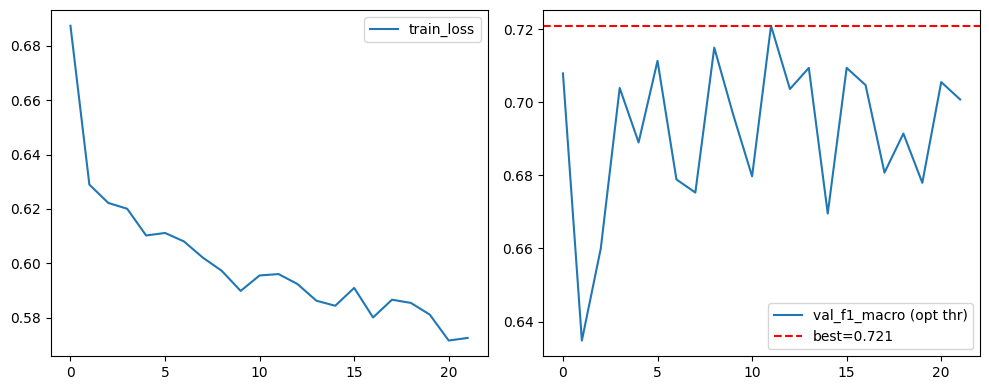

PosixPath('/Users/dk/Desktop/ВШЭ/ВКР/HSE_VKR_DetectingSpeechDefects/experiments/02_spectrogram_models/exp_dsscnet/result.csv')

In [6]:
train_utils.load_best_checkpoint(model, best_ckpt, DEVICE)

print(f"Обучение: {train_time_sec:.1f} с | best_val_f1={best_f1:.4f}")

val_proba, val_true = eval_loader(val_loader)
optimal_threshold = find_optimal_threshold(val_true, val_proba)
test_proba, test_true = eval_loader(test_loader)
test_metrics = evaluate(test_true, test_proba, threshold=optimal_threshold, verbose=True)
pd.DataFrame({
    "path":    paths_test,
    "y_true":  test_true,
    "y_pred":  (test_proba >= optimal_threshold).astype(int),
    "y_proba": test_proba,
}).to_csv(exp_dir / "test_predictions.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(train_losses, label="train_loss"); axes[0].legend()
axes[1].plot(val_f1s, label="val_f1_macro (opt thr)")
axes[1].axhline(best_f1, color="r", linestyle="--", label=f"best={best_f1:.3f}"); axes[1].legend()
plt.tight_layout()
fig.savefig(exp_dir / "training_curves.png", dpi=120)
plt.show()

save_result_csv(
    exp_dir=exp_dir, experiment_id="exp_dsscnet",
    experiment_name="DSSCNet (SE+Res) на mel + SpecAugment",
    accuracy=test_metrics["accuracy"], f1_macro=test_metrics["f1_macro"],
    f1_bad=test_metrics["f1_bad"],     roc_auc=test_metrics["roc_auc"],
    precision_bad=test_metrics["precision_bad"], recall_bad=test_metrics["recall_bad"],
    threshold=test_metrics["threshold"],
    embed_dim=64,
    embed_dim_note="SE-ResNet base_c=64, global avg pool  fc=Linear(64+n_letters)",
    notes=f"SpecAugment + test | thr={optimal_threshold:.2f} | n_mels={N_MELS} frames={N_FRAMES} | ckpt by val_f1(opt_thr)",
    num_params=n_params, train_time_sec=train_time_sec,
)